In [2]:
import scqubits as scq
import numpy as np
import pandas as pd
import qutip
import csv 
import matplotlib.pyplot as plt
from scipy.constants import hbar
from scipy.optimize import least_squares
from qutip import mesolve, sigmax, sigmay, sigmaz, identity
from tabulate import tabulate
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider


=== Initial Guess (from transmon approx) ===
EJ = 17.596
EC = 0.166

=== Fitted Parameters (GHz) ===
EJ_fit = 19.012870 (R = 5.260 kOhm)
EC_fit = 0.153152
EJ/EC = 124.144087

=== Targets vs Fitted (GHz) ===
Target  f01      = 4.668000,   Fitted f01      = 4.668000,   Δ = -1.258549e-12
Target  f02/2    = 4.585000,   Fitted f02/2    = 4.585000,   Δ = -1.270983e-12


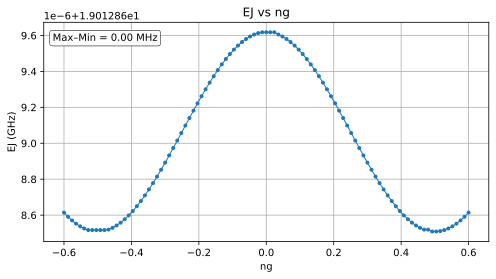

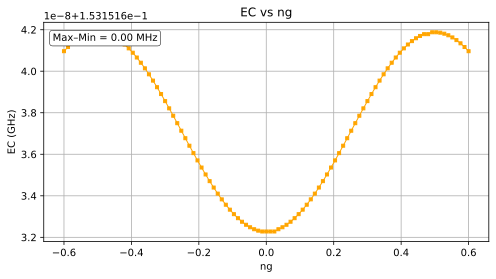

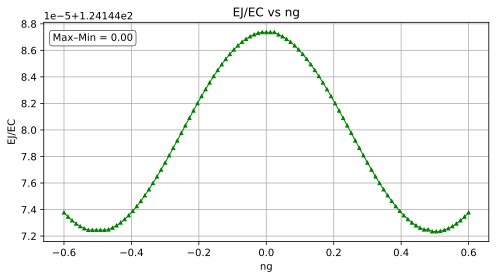

In [6]:
# ===== 你的量測/目標值（單位 GHz）=====
f01_measured = 4.668      # 例：E01
f02_over_2_measured = 4.585# 例：E02/2  (注意：E02/2 = (E01 + E12)/2)

# ===== 與你一致的模型與截斷參數 =====
ng = 0.0
ncut = 20
truncated_dim = 6

def f01_f02_from_EJ_EC(EJ, EC, ng, ncut, truncated_dim):
    """回傳 (E01, E02/2)。皆為 GHz。"""
    tmon = scq.Transmon(EJ=EJ, EC=EC, ng=ng, ncut=ncut, truncated_dim=truncated_dim)
    eigenvals = tmon.eigenvals(evals_count=3, filename=None, return_spectrumdata=False)
    f01 = eigenvals[1] - eigenvals[0]
    f02_over_2 = (eigenvals[2] - eigenvals[0]) / 2
    return f01, f02_over_2
def transmon_guess_from_f01_f02over2(f01, f02_over_2):
    EC = 2.0 * (f01 - f02_over_2)
    EJ = ((f01 + EC)**2) / (8.0 * EC)
    return EJ, EC

# 初始猜測
EJ0, EC0 = transmon_guess_from_f01_f02over2(f01_measured, f02_over_2_measured)

def residuals(x):
    EJ = x[0]
    EC = x[1]
    # 邊界保護：避免負值或數值崩潰
    if EJ <= 0 or EC <= 0:
        return np.array([1e6, 1e6])
    f01, f02_over_2 = f01_f02_from_EJ_EC(EJ, EC, ng=ng, ncut=ncut, truncated_dim=truncated_dim)
    # 你也可以加權，例如更重視 E01：r = [w1*(E01-Target), w2*(E02/2-Target)]
    r1 = f01 - f01_measured
    r2 = f02_over_2 - f02_over_2_measured
    return np.array([r1, r2])

# 用 least_squares 拟合，加入合理 bounds
bounds = ([1e-9, 1e-9], [100, 1])  # EJ ∈ (0, 100 GHz), EC ∈ (0, 1 GHz)，可依需求調整
tol = dict(xtol=1e-10, ftol=1e-10, gtol=1e-10)
res = least_squares(residuals, x0=[EJ0, EC0], bounds=bounds, **tol)

EJ_fit, EC_fit = res.x
f01_fit, f02_over_2_fit = f01_f02_from_EJ_EC(EJ_fit, EC_fit, ng=ng, ncut=ncut, truncated_dim=truncated_dim)
R = 100.0 / EJ_fit  # kOhm

print("\n=== Initial Guess (from transmon approx) ===")
print(f"EJ = {EJ0:.3f}")
print(f"EC = {EC0:.3f}")

print("\n=== Fitted Parameters (GHz) ===")
print(f"EJ_fit = {EJ_fit:.6f} (R = {R:.3f} kOhm)")
print(f"EC_fit = {EC_fit:.6f}")
print(f"EJ/EC = {EJ_fit/EC_fit:.6f}")

print("\n=== Targets vs Fitted (GHz) ===")
print(f"Target  f01      = {f01_measured:.6f},   Fitted f01      = {f01_fit:.6f},   Δ = {f01_fit-f01_measured:+.6e}")
print(f"Target  f02/2    = {f02_over_2_measured:.6f},   Fitted f02/2    = {f02_over_2_fit:.6f},   Δ = {f02_over_2_fit-f02_over_2_measured:+.6e}")

# 全域初始猜測，用於掃描 ng 時的 warm start

def fit_EJ_EC_for_ng(ng, x0):
    """給定 ng 與初始 x0=[EJ,EC]，擬合最接近 target_E01, target_E02/2 的 EJ, EC。"""
    def residuals(x):
        EJ = x[0]
        EC = x[1]
        # 防呆：避免非物理解
        if EJ <= 0 or EC <= 0:
            return np.array([1e6, 1e6])
        f01, f02_over_2 = f01_f02_from_EJ_EC(EJ, EC, ng=ng, ncut=ncut, truncated_dim=truncated_dim)
        r1 = f01 - f01_measured
        r2 = f02_over_2 - f02_over_2_measured
        return np.array([r1, r2])
    bounds = ([1e-9, 1e-9], [100, 1])  # EJ ∈ (0, 100 GHz), EC ∈ (0, 1 GHz)，可依需求調整
    tol = dict(xtol=1e-10, ftol=1e-10, gtol=1e-10)
    res = least_squares(residuals, x0=x0, bounds=bounds, **tol)
    return res

# 掃描 ng 並列印結果
ng_grid = np.linspace(-0.6, 0.6, 101)
results = []  # 收集 (ng, EJ_fit, EC_fit, E01_fit, E02o2_fit, success)

x0 = np.array([EJ0, EC0], dtype=float)  # 第一個 ng 的初始值
rows = []

for ng in ng_grid:
    res = fit_EJ_EC_for_ng(ng, x0)
    EJ_fit, EC_fit = res.x
    f01_fit, f02_over_2_fit = f01_f02_from_EJ_EC(EJ_fit, EC_fit, ng=ng, ncut=ncut, truncated_dim=truncated_dim)
    rows.append({
        "ng": ng,
        "EJ_fit(GHz)": EJ_fit,
        "EC_fit(GHz)": EC_fit,
        "EJ/EC": EJ_fit/EC_fit,
        "f01_fit(GHz)": f01_fit,
        "f02/2_fit(GHz)": f02_over_2_fit,
        "Δf01": f01_fit - f01_measured,
        "Δf02/2": f02_over_2_fit - f02_over_2_measured,
        "success": res.success
    })
    x0 = res.x.copy()  # warm start

# 轉成表格
df = pd.DataFrame(rows)

# 轉 Markdown 格式表格，帶格線
table_str = tabulate(df, headers="keys", tablefmt="grid", showindex=False, floatfmt=".3f")

# === 畫 EJ vs ng ===
EJ_vals = df["EJ_fit(GHz)"]
EJ_range = (EJ_vals.max() - EJ_vals.min())*1000

plt.figure(figsize=(7,4))
plt.plot(df["ng"], EJ_vals, marker="o", markersize=3, linewidth=1)
plt.xlabel("ng")
plt.ylabel("EJ (GHz)")
plt.title("EJ vs ng")
plt.grid(True)

# 在右上角加文字顯示範圍
plt.text(0.02, 0.95, f"Max–Min = {EJ_range:.2f} MHz",
         transform=plt.gca().transAxes, ha="left", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5))

plt.tight_layout()
plt.show()


# === 畫 EC vs ng ===
EC_vals = df["EC_fit(GHz)"]
EC_range = (EC_vals.max() - EC_vals.min())*1000

plt.figure(figsize=(7,4))
plt.plot(df["ng"], EC_vals, marker="s", color="orange", markersize=3, linewidth=1)
plt.xlabel("ng")
plt.ylabel("EC (GHz)")
plt.title("EC vs ng")
plt.grid(True)

# 在右上角加文字顯示範圍
plt.text(0.02, 0.95, f"Max–Min = {EC_range:.2f} MHz",
         transform=plt.gca().transAxes, ha="left", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5))

plt.tight_layout()
plt.show()

# === 畫 EJ/EC vs ng ===
ratio_vals = df["EJ_fit(GHz)"] / df["EC_fit(GHz)"]
ratio_range = ratio_vals.max() - ratio_vals.min()

plt.figure(figsize=(7,4))
plt.plot(df["ng"], ratio_vals, marker="^", color="green", markersize=3, linewidth=1)
plt.xlabel("ng")
plt.ylabel("EJ/EC")
plt.title("EJ/EC vs ng")
plt.grid(True)

# 在右上角顯示 Max–Min
plt.text(0.02, 0.95, f"Max–Min = {ratio_range:.2f}",
         transform=plt.gca().transAxes, ha="left", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5))

plt.tight_layout()
plt.show()

# 把第一行 (標題列) 置中
lines = table_str.split("\n")
header = lines[2]  # tabulate 會在第2行是 header
header_centered = "| " + " | ".join([h.strip().center(len(h.strip())+2) for h in header.split("|")[1:-1]]) + " |"
lines[2] = header_centered
table_str = "\n".join(lines)

# print(table_str)

In [5]:
# -----------------------------
# 固定參數
# -----------------------------
N_cut  = 10
N_tmon = 6
N_res  = 120
fr_bare_measured     = 4.5439112675         # ex: GHz

# 初始值
INIT_EJ      = 8.571329       # GHz
INIT_EC      = 0.175861       # GHz
INIT_G       = 0.026          # GHz

# 量測值（GHz）
f01_measured          = 3.28636093462153      # ex: GHz
f02_over_2_measured    = 3.18506775266031    # ex: GHz
fr_dressed_measured  = 4.54444668                # ex: GHz

# -----------------------------
# 工具函式：建立系統並回傳 f01 與 f02/2
# -----------------------------
def compute_observables(EJ, EC, g, fr_bare, N_cut=10, N_tmon=6, N_res=120):
    """
    由 (EJ, EC, fr_bare, g) 建構 Transmon + Oscillator + HilbertSpace
    回傳：
        f01 (GHz),
        f02_over2 = (E2 - E0)/2 (GHz)
    說明：
        - 用 (i, k) 的 'bare indices' 表示：i=transmon-level, k=resonator-photon
        - 取 fixed resonator index k=0（真空態）下的 dressed energies 的差
        - 以 energies_fix_second_index(0) 的作法抓 (i, 0) 的能量
    """
    # 1) 建立元件
    tmon = scq.Transmon(EJ=EJ, EC=EC, ng=0.0, ncut=N_cut, truncated_dim=N_tmon)
    res  = scq.Oscillator(E_osc=fr_bare, truncated_dim=N_res)

    # 2) Hilbert space
    hs = scq.HilbertSpace([tmon, res])

    # 3) 相互作用：n ⊗ (a + a†)
    op1 = tmon.n_operator()
    op2 = res.creation_operator() + res.annihilation_operator()

    hs.add_interaction(g=g, op1=(op1, tmon), op2=(op2, res))

    # 4) 哈密頓量與本徵值
    H = hs.hamiltonian()
    evals, evecs = H.eigenstates()  # dense；若慢，可改 eigenenergies()

    # 5) 產生索引查表與讀取 dressed energies
    hs.generate_lookup(ordering="LX")  # 'L'是 transmon, 'X'是 oscillator 的慣例

    # energies at fixed resonator index k=0, varying transmon index i
    max_i = N_tmon - 1
    i_arr = np.arange(max_i + 1, dtype=int)
    E_i0  = np.array([
        hs.energy_by_dressed_index(hs.dressed_index((i, 0)))
        for i in i_arr
    ])

    max_i = N_res - 1
    i_arr = np.arange(max_i + 1, dtype=int)
    E_0i  = np.array([
        hs.energy_by_dressed_index(hs.dressed_index((0, i)))
        for i in i_arr
    ])

    # 6) 轉成頻率差
    # E0, E1, E2 -> f01 = E1 - E0; f12 = E2 - E1; f02/2 = (E2 - E0)/2
    if len(E_i0) < 3:
        raise RuntimeError("N_tmon 必須 >= 3 才能計算 f02/2")
    f01        = E_i0[1] - E_i0[0]
    f02_over2  = (E_i0[2] - E_i0[0]) / 2.0
    fr_dressed = E_0i[1] - E_0i[0]

    return float(f01), float(f02_over2), float(fr_dressed)

# -----------------------------
# 殘差函式（least_squares 用）
# -----------------------------
def residuals_vec(params, target):
    EJ, EC, g = params
    f01_measured, f02_over_2_measured, fr_dressed_measured = target  # 目標（量測）

    # 基本物理解域（避免非物理解）
    if EJ <= 0 or EC <= 0 or g <= 0:
        # 給很大的殘差，讓優化器遠離
        return np.array([1e6, 1e6, 1e6], dtype=float)

    try:
        f01, f02_over_2, fr_dressed = compute_observables(
            EJ, EC, g, 
            fr_bare=fr_bare_measured, N_cut=N_cut, N_tmon=N_tmon, N_res=N_res
        )
        
    except Exception as e:
        # 若對角化或生成 lookup 失敗，以大殘差懲罰
        return np.array([1e6, 1e6, 1e6], dtype=float)

    # 殘差（可依相對/絕對誤差取捨；這裡用絕對差）
    r1 = f01 - f01_measured
    r2 = f02_over_2 - f02_over_2_measured
    r3 = fr_dressed - fr_dressed_measured
    return np.array([r1, r2, r3], dtype=float)

# -----------------------------
# 配適主流程
# -----------------------------
def fit_params_from(f01_measured, f02_over_2_measured, fr_dressed_measured,
                    init_params=None,
                    bounds=None,
                    verbose=2):
    """
    以 (f01, f02/2) 反推 (EJ, EC, fr_bare, g)
    - init_params: 初始猜測 [EJ, EC, g]
    - bounds: 參數邊界 ([lower], [upper])；若不給，使用合理預設
    回傳：
        result.x = [EJ, EC, fr_bare, g]
        以及擬合後的 model f01/f02/2
    """
    if init_params is None:
        init_params = np.array([INIT_EJ, INIT_EC, INIT_G], dtype=float)

    if bounds is None:
        # 合理的邊界（你可依系統調整）
        # EJ: [0.1, 60]; EC: [0.02, 2]; g: [1e-4, 0.2]
        lb = np.array([0.1, 0.02, 1e-4], dtype=float)
        ub = np.array([60., 2.00, 0.20], dtype=float)
        bounds = (lb, ub)

    target = np.array([f01_measured, f02_over_2_measured, fr_dressed_measured], dtype=float)

    result = least_squares(
        fun=lambda p: residuals_vec(p, target),
        x0=init_params,
        bounds=bounds,
        method="trf",
        verbose=verbose,
        xtol=1e-10, ftol=1e-10, gtol=1e-10,
        max_nfev=200
    )

    # 計算擬合後的 observable
    EJ_f, EC_f, G_f = result.x
    f01_fit, f02_over_2_fit, fr_dressed_fit = compute_observables(
        EJ_f, EC_f, G_f, fr_bare=fr_bare_measured, N_cut=N_cut, N_tmon=N_tmon, N_res=N_res
    )

    report = {
        "success": result.success,
        "message": result.message,
        "nfev": result.nfev,
        "cost": 2.0 * result.cost,  # sum of squares
        "residuals": result.fun.copy(),
        "params": {
            "EJ": EJ_f,
            "EC": EC_f,
            "g": G_f,
        },
        "observables_fit": {
            "f01": f01_fit,
            "f02_over_2": f02_over_2_fit,
            "fr_dressed": fr_dressed_fit
        },
        "observables_target": {
            "f01": float(f01_measured),
            "f02_over_2": float(f02_over_2_measured),
            "fr_dressed": float(fr_dressed_measured)
        }
    }
    return report

# -----------------------------
# 範例執行
# -----------------------------
if __name__ == "__main__":
    # 你可以把 init_params 設成你 forward 的那組，幫助收斂
    init_params = np.array([INIT_EJ, INIT_EC, INIT_G], dtype=float)

    # 也可以手動設邊界更緊一些（收斂更穩）
    bounds = (
        np.array([0.1, 0.02, 1e-4], dtype=float),
        np.array([40., 1.00, 0.20], dtype=float),
    )

    rep = fit_params_from(
        f01_measured=f01_measured,
        f02_over_2_measured=f02_over_2_measured,
        fr_dressed_measured=fr_dressed_measured,
        init_params=init_params,
        bounds=bounds,
        verbose=2
    )

    print("\n=== Fit Report ===")
    print("Success:", rep["success"])
    print("Message:", rep["message"])
    print("Function evals:", rep["nfev"])
    print("Sum of squares:", rep["cost"])
    print("\n-- Params (GHz) --")
    for k, v in rep["params"].items():
        print(f"{k:8s} = {v:.6f}")
    print("\n-- Observables (GHz) --")
    print("Target: f01 = %.6f, f02/2 = %.6f, fr_dressed = %.6f" % (rep["observables_target"]["f01"],
                                                                   rep["observables_target"]["f02_over_2"],
                                                                   rep["observables_target"]["fr_dressed"]))
    print("  Fit : f01 = %.6f, f02/2 = %.6f, fr_dressed = %.6f" % (rep["observables_fit"]["f01"],
                                                                   rep["observables_fit"]["f02_over_2"],
                                                                   rep["observables_fit"]["fr_dressed"]))

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.3329e-07                                    9.17e-03    
       1              2         5.1162e-11      4.33e-07       4.05e-03       1.54e-05    
       2              3         1.6307e-15      5.12e-11       7.54e-04       5.43e-07    


KeyboardInterrupt: 

Eigenvalues (GHz):
[0.         3.28465954 4.54515642 6.36798193 7.82926442 9.09031242]
dE0n (first 5): ['4.545156', '4.545156', '4.545156', '4.545155', '4.545155']
dE0n (last  5): ['4.545036', '4.545035', '4.545038', '4.545579', '4.583354']
dEn0 (first 5): ['3.284660', '3.083322']
f01 = 3.2847 GHz, f12 = 3.0833 GHz, alpha = -0.2013 GHz
delta = -1.2593 GHz
chi = -1.270596 MHz
Chi_eff = 0.175147 MHz
n_critical = 247.767953


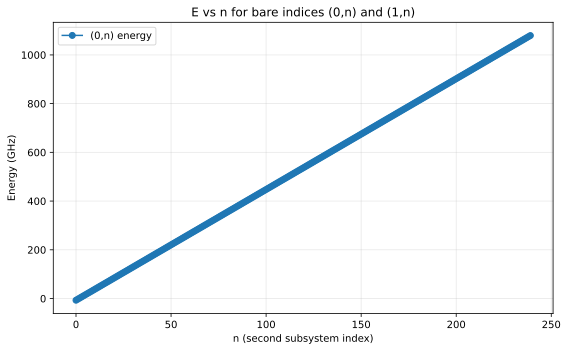

 C:\Users\shiau\AppData\Local\Temp\ipykernel_40180\1213896508.py: 124

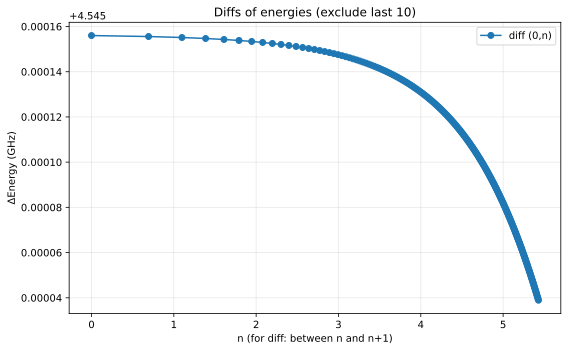

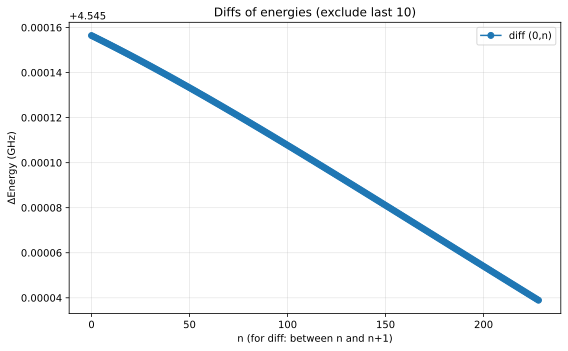

In [ ]:
# truncated dimension of the transmon and the resonator
N_cut, N_tmon, N_res =10, 3, 240
EJ = 8.571329
EC = 0.175861
fr_bare = 4.5439112675
g = 0.04

tmon1 = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ng=0,
    ncut=N_cut,
    truncated_dim=N_tmon     # after diagonalization, we will keep levels 0, 1, 2, and 3
)
resonator = scq.Oscillator(
    E_osc=fr_bare,
    # l_osc= 2.0,
    truncated_dim=N_res  # up to 3 photons (0,1,2,3)
)

hilbertspace = scq.HilbertSpace([tmon1, resonator])

operator1 = tmon1.n_operator()
operator2 = resonator.creation_operator() + resonator.annihilation_operator()

hilbertspace.add_interaction(
    g=g,
    op1=(operator1, tmon1),
    op2=(operator2, resonator)
)

H = hilbertspace.hamiltonian()

# print(hilbertspace.interaction_hamiltonian())

eigvals, eigvecs = H.eigenstates()

# 找最小值
emin = np.min(eigvals)

# 全部減去最小值
eigvals_shifted = eigvals - emin

print("Eigenvalues (GHz):")
print(eigvals_shifted[:6])   # 前六個能階

# --- 1) 先建 lookup（LX）與基本量 ---
hilbertspace.generate_lookup(ordering="LX")

def energies_fix_first_index(k: int):
    max_n = N_res - 1
    i_arr = np.arange(max_n+1, dtype=int)
    E = np.array([
        hilbertspace.energy_by_dressed_index(hilbertspace.dressed_index((k, i)))
        for i in i_arr
    ])
    return i_arr, E
def energies_fix_second_index(k: int):
    max_n = N_tmon - 1
    i_arr = np.arange(max_n+1, dtype=int)
    E = np.array([
        hilbertspace.energy_by_dressed_index(hilbertspace.dressed_index((i, k)))
        for i in i_arr
    ])
    return i_arr, E

# --- 3) 拿 (0,n) 與 (1,n) 的能量與差分 ---
v0n, E0n = energies_fix_first_index(0)
v1n, E1n = energies_fix_first_index(1)
# v2n, E2n = energies_fix_first_index(2)
vn0, En0 = energies_fix_second_index(0)

dE0n = np.diff(E0n)
dE1n = np.diff(E1n)
# dE2n = np.diff(E2n)
dEn0 = np.diff(En0)
f01_n = E1n - E0n

# 只看前/後 5 筆（跟你之前輸出一致）
print("dE0n (first 5):", [f"{d:.6f}" for d in dE0n[:5]])
print("dE0n (last  5):", [f"{d:.6f}" for d in dE0n[-5:]])
# print("dE1n (first 5):", [f"{d:.6f}" for d in dE1n[:15]])
# print("dE1n (last  5):", [f"{d:.6f}" for d in dE1n[-5:]])
print("dEn0 (first 5):", [f"{d:.6f}" for d in dEn0[:5]])

# assert np.array_equal(n0, n1), "兩條曲線 n 範圍需一致"
# n = n0

# ========== 理論線 ==========
alpha = dEn0[1] - dEn0[0]
delta = dEn0[0] - fr_bare

# 理論 χ 與 shift
chi = g**2 / delta
fr_bare_theory = fr_bare - chi
chi_eff = - (g**2 / delta) * (1 / (1 + delta/alpha))
# chi_eff = chi - 0.0149**2 / 2 / (dEn0[1] - fr_bare)
nc = delta**2 / (4 * g**2)

print(f"f01 = {dEn0[0]:.4f} GHz, f12 = {dEn0[1]:.4f} GHz, alpha = {alpha:.4f} GHz")
print(f"delta = {delta:.4f} GHz")
print(f"chi = {chi*1000:.6f} MHz")
print(f"Chi_eff = {chi_eff*1000:.6f} MHz")
print(f"n_critical = {nc:.6f}")

# --- 4) 畫圖：能量 vs n（兩條線合併）---
plt.figure(figsize=(8,5))
plt.plot(v0n, E0n, marker='o', label='(0,n) energy')
plt.xlabel('n (second subsystem index)')
plt.ylabel('Energy (GHz)')
plt.title('E vs n for bare indices (0,n) and (1,n)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- 5) 畫圖：差分 vs n（兩條線合併）---
# 注意：diff 的橫軸對應到「相鄰 n 的間隔」，所以用 n[:-1]
# 若要砍掉最後 3 個點，可在這裡裁切

drop_last = 10

plt.figure(figsize=(8,5))
plt.plot(np.log(v0n[:-1 - drop_last]), dE0n[:-drop_last], marker='o', label='diff (0,n)')
plt.xlabel('n (for diff: between n and n+1)')
plt.ylabel('ΔEnergy (GHz)')
plt.title(f'Diffs of energies (exclude last {drop_last})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(v0n[:-1 - drop_last], dE0n[:-drop_last], marker='o', label='diff (0,n)')
plt.xlabel('n (for diff: between n and n+1)')
plt.ylabel('ΔEnergy (GHz)')
plt.title(f'Diffs of energies (exclude last {drop_last})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

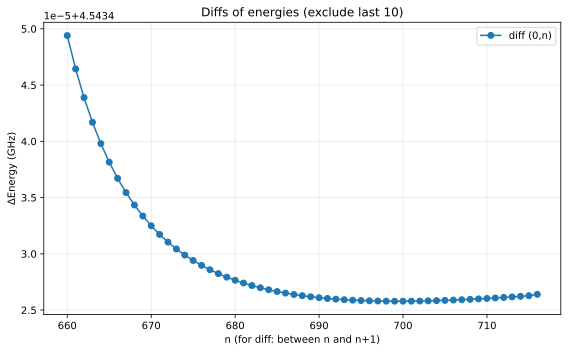

4.543425789424418


In [14]:
plt.figure(figsize=(8,5))
plt.plot(v0n[660:717], dE0n[660:717], marker='o', label='diff (0,n)')
plt.xlabel('n (for diff: between n and n+1)')
plt.ylabel('ΔEnergy (GHz)')
plt.title(f'Diffs of energies (exclude last {drop_last})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

sub_min = dE0n[690:710].min()
print(sub_min)

In [2]:
# -----------------------------
# 固定參數
# -----------------------------
N_cut  = 10
N_tmon = 6
N_res  = 800

# 初始值
INIT_EJ      = 8.571329       # GHz
INIT_EC      = 0.175861       # GHz
INIT_G       = 0.026          # GHz
INIT_FR_INPUT = 4.543425789424418  # GHz

# 量測值（GHz）
f01_measured          = 3.28636093462153      # ex: GHz
f02_over_2_measured    = 3.18506775266031    # ex: GHz
fr_dressed_measured  = 4.54444668                # ex: GHz
fr_bare_measured     = 4.5439112675         # ex: GHz

# -----------------------------
# 工具函式：建立系統並回傳 f01 與 f02/2
# -----------------------------
def compute_observables(EJ, EC, g, fr_bare_input, N_cut=10, N_tmon=6, N_res=120):
    """
    由 (EJ, EC, fr_bare, g) 建構 Transmon + Oscillator + HilbertSpace
    回傳：
        f01 (GHz),
        f02_over2 = (E2 - E0)/2 (GHz)
    說明：
        - 用 (i, k) 的 'bare indices' 表示：i=transmon-level, k=resonator-photon
        - 取 fixed resonator index k=0（真空態）下的 dressed energies 的差
        - 以 energies_fix_second_index(0) 的作法抓 (i, 0) 的能量
    """
    # 1) 建立元件
    tmon = scq.Transmon(EJ=EJ, EC=EC, ng=0.0, ncut=N_cut, truncated_dim=N_tmon)
    res  = scq.Oscillator(E_osc=fr_bare_input, truncated_dim=N_res)

    # 2) Hilbert space
    hs = scq.HilbertSpace([tmon, res])

    # 3) 相互作用：n ⊗ (a + a†)
    op1 = tmon.n_operator()
    op2 = res.creation_operator() + res.annihilation_operator()

    hs.add_interaction(g=g, op1=(op1, tmon), op2=(op2, res))

    # 4) 哈密頓量與本徵值
    H = hs.hamiltonian()
    evals, evecs = H.eigenstates()  # dense；若慢，可改 eigenenergies()

    # 5) 產生索引查表與讀取 dressed energies
    hs.generate_lookup(ordering="LX")  # 'L'是 transmon, 'X'是 oscillator 的慣例

    # energies at fixed resonator index k=0, varying transmon index i
    max_i = N_tmon - 1
    i_arr = np.arange(max_i + 1, dtype=int)
    E_i0  = np.array([
        hs.energy_by_dressed_index(hs.dressed_index((i, 0)))
        for i in i_arr
    ])

    max_i = N_res - 1
    i_arr = np.arange(max_i + 1, dtype=int)
    E_0i  = np.array([
        hs.energy_by_dressed_index(hs.dressed_index((0, i)))
        for i in i_arr
    ])

    # 6) 轉成頻率差
    # E0, E1, E2 -> f01 = E1 - E0; f12 = E2 - E1; f02/2 = (E2 - E0)/2
    if len(E_i0) < 3:
        raise RuntimeError("N_tmon 必須 >= 3 才能計算 f02/2")
    f01        = E_i0[1] - E_i0[0]
    f02_over2  = (E_i0[2] - E_i0[0]) / 2.0
    fr_dressed = E_0i[1] - E_0i[0]
    dE0i = np.diff(E_0i)
    fr_bare = dE0i[:-round(N_res * 0.02)].min()
    if np.abs(fr_bare-fr_bare_input) > 0.005:
        raise RuntimeError("fr_bare 計算錯誤")

    return float(f01), float(f02_over2), float(fr_dressed), float(fr_bare)

# -----------------------------
# 殘差函式（least_squares 用）
# -----------------------------
def residuals_vec(params, target):
    EJ, EC, g , fr_bare_input = params
    f01_measured, f02_over_2_measured, fr_dressed_measured, fr_bare_measured = target  # 目標（量測）

    # 基本物理解域（避免非物理解）
    if EJ <= 0 or EC <= 0 or g <= 0:
        # 給很大的殘差，讓優化器遠離
        return np.array([1e6, 1e6, 1e6], dtype=float)

    try:
        f01, f02_over_2, fr_dressed, fr_bare = compute_observables(
            EJ, EC, g, fr_bare_input,
            N_cut=N_cut, N_tmon=N_tmon, N_res=N_res
        )
        
    except Exception as e:
        # 若對角化或生成 lookup 失敗，以大殘差懲罰
        return np.array([1e6, 1e6, 1e6, 1e6], dtype=float)

    # 殘差（可依相對/絕對誤差取捨；這裡用絕對差）
    r1 = f01 - f01_measured
    r2 = f02_over_2 - f02_over_2_measured
    r3 = fr_dressed - fr_dressed_measured
    r4 = fr_bare - fr_bare_measured

    return np.array([r1, r2, r3, r4], dtype=float)

# -----------------------------
# 配適主流程
# -----------------------------
def fit_params_from(f01_measured, f02_over_2_measured, fr_dressed_measured, fr_bare_measured,
                    init_params=None,
                    bounds=None,
                    verbose=2):
    """
    以 (f01, f02/2) 反推 (EJ, EC, fr_bare, g)
    - init_params: 初始猜測 [EJ, EC, g]
    - bounds: 參數邊界 ([lower], [upper])；若不給，使用合理預設
    回傳：
        result.x = [EJ, EC, fr_bare, g]
        以及擬合後的 model f01/f02/2
    """
    if init_params is None:
        init_params = np.array([INIT_EJ, INIT_EC, INIT_G, INIT_FR_INPUT], dtype=float)

    if bounds is None:
        # 合理的邊界（你可依系統調整）
        # EJ: [0.1, 60]; EC: [0.02, 2]; g: [1e-4, 0.2]
        lb = np.array([0.1, 0.02, 1e-4, 1e-4], dtype=float)
        ub = np.array([60., 2.00, 0.20, 9.0], dtype=float)
        bounds = (lb, ub)

    target = np.array([f01_measured, f02_over_2_measured, fr_dressed_measured, fr_bare_measured], dtype=float)

    result = least_squares(
        fun=lambda p: residuals_vec(p, target),
        x0=init_params,
        bounds=bounds,
        method="trf",
        verbose=verbose,
        xtol=1e-10, ftol=1e-10, gtol=1e-10,
        max_nfev=200
    )

    # 計算擬合後的 observable
    EJ_f, EC_f, G_f, fr_bare_f = result.x
    f01_fit, f02_over_2_fit, fr_dressed_fit, fr_bare_fit = compute_observables(
        EJ_f, EC_f, G_f, fr_bare_f, N_cut=N_cut, N_tmon=N_tmon, N_res=N_res
    )

    report = {
        "success": result.success,
        "message": result.message,
        "nfev": result.nfev,
        "cost": 2.0 * result.cost,  # sum of squares
        "residuals": result.fun.copy(),
        "params": {
            "EJ": EJ_f,
            "EC": EC_f,
            "g": G_f,
            "fr_bare": fr_bare_f,
        },
        "observables_fit": {
            "f01": f01_fit,
            "f02_over_2": f02_over_2_fit,
            "fr_dressed": fr_dressed_fit,
            "fr_bare": fr_bare_fit
        },
        "observables_target": {
            "f01": float(f01_measured),
            "f02_over_2": float(f02_over_2_measured),
            "fr_dressed": float(fr_dressed_measured),
            "fr_bare": float(fr_bare_measured)
        }
    }
    return report

# -----------------------------
# 範例執行
# -----------------------------
if __name__ == "__main__":
    # 你可以把 init_params 設成你 forward 的那組，幫助收斂
    init_params = np.array([INIT_EJ, INIT_EC, INIT_G, INIT_FR_INPUT], dtype=float)

    # 也可以手動設邊界更緊一些（收斂更穩）
    bounds = (
        np.array([0.1, 0.02, 1e-4, 1e-4], dtype=float),
        np.array([40., 1.00, 0.20, 9.0], dtype=float),
    )

    rep = fit_params_from(
        f01_measured=f01_measured,
        f02_over_2_measured=f02_over_2_measured,
        fr_dressed_measured=fr_dressed_measured,
        fr_bare_measured=fr_bare_measured,
        init_params=init_params,
        bounds=bounds,
        verbose=2
    )

    print("\n=== Fit Report ===")
    print("Success:", rep["success"])
    print("Message:", rep["message"])
    print("Function evals:", rep["nfev"])
    print("Sum of squares:", rep["cost"])
    print("\n-- Params (GHz) --")
    for k, v in rep["params"].items():
        print(f"{k:8s} = {v:.6f}")
    print("\n-- Observables (GHz) --")
    print("Target: f01 = %.6f, f02/2 = %.6f, fr_dressed = %.6f, fr_bare = %.6f" % (rep["observables_target"]["f01"],
                                                                                rep["observables_target"]["f02_over_2"],
                                                                                rep["observables_target"]["fr_dressed"],
                                                                                rep["observables_target"]["fr_bare"]))
    print("  Fit : f01 = %.6f, f02/2 = %.6f, fr_dressed = %.6f, fr_bare = %.6f" % (rep["observables_fit"]["f01"],
                                                                                rep["observables_fit"]["f02_over_2"],
                                                                                rep["observables_fit"]["fr_dressed"],
                                                                                rep["observables_fit"]["fr_bare"]))

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.2327e-06                                    9.18e-03    
       1              2         3.1505e-08      1.20e-06       4.88e-03       2.01e-04    
       2              4         1.9943e-08      1.16e-08       9.45e-04       1.13e-05    
       3              6         1.5456e-08      4.49e-09       4.80e-04       2.77e-06    
       4              7         4.6555e-09      1.08e-08       9.37e-04       2.87e-04    
       5              9         1.6385e-09      3.02e-09       1.03e-04       4.85e-05    
       6             10         8.7341e-10      7.65e-10       8.17e-05       1.65e-04    
       7             11         4.3212e-12      8.69e-10       1.61e-05       1.18e-05    
       8             12         2.0729e-16      4.32e-12       1.26e-06       8.20e-08    
       9             13         6.3071e-24      2.07e-16       2.42e-08       2.21e-11    

Transmon------------| [Transmon_12]
                    | EJ: 5
                    | EC: 0.5
                    | ng: 0.5
                    | ncut: 20
                    | truncated_dim: 3
                    |
                    | dim: 41

[-2.8950403   0.92909377  4.61816386  5.77441602 12.75540802 12.77498587]
[3.82413407 3.68907009 1.15625216 6.980992   0.01957785]
Eigenvalues (GHz):
[0.         3.82301635 4.5448971  7.51202965 8.36707813 9.08979318]
dE0n (first 5): ['4.544897', '4.544896', '4.544895', '4.544894', '4.544893']
dE1n (first 5): ['4.544062', '4.544061', '4.544060', '4.544059', '4.544059', '4.544058', '4.544057', '4.544056', '4.544055', '4.544055', '4.544054', '4.544053', '4.544052', '4.544052', '4.544051']
dEn0 (first 5): ['3.823016', '3.689013']
f01 = 3.8230 GHz
f12 = 3.6890 GHz, alpha = -0.1340 GHz
delta = -0.7209 GHz
g = 40.021000 MHz
chi = 0.986102 MHz
Chi_eff = 0.835321 MHz
n_critical = 81.116227


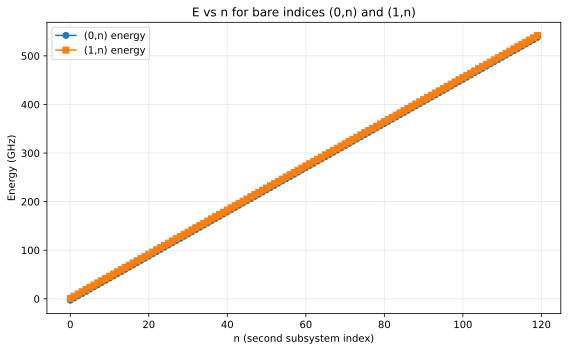

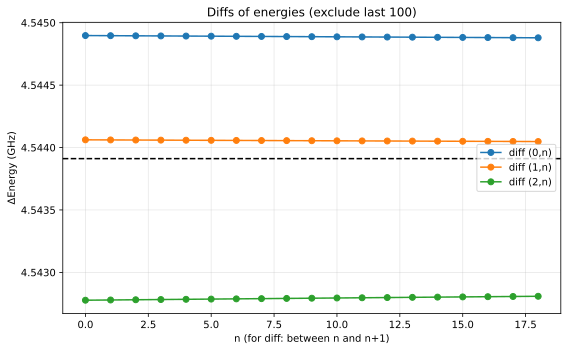

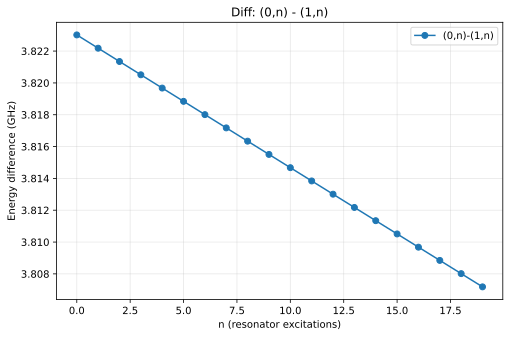

In [ ]:
# truncated dimension of the transmon and the resonator
N_cut, N_tmon, N_res =20, 3, 120


fr_bare_measured = 4.543911 #dE0n[:-round(N_res * 0.02)].min()

EJ = 8
EC = 2.78
print(f"EJ/EC = {EJ/EC:.2f}")
fr_bare = fr_bare_measured
g = 0.040021 #0.026230

tmon1 = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ng=0.5,
    ncut=N_cut,
    truncated_dim=N_tmon     # after diagonalization, we will keep levels 0, 1, 2, and 3
)
print(tmon1)
resonator = scq.Oscillator(
    E_osc=fr_bare,
    # l_osc= 2.0,
    truncated_dim=N_res  # up to 3 photons (0,1,2,3)
)

hilbertspace = scq.HilbertSpace([tmon1, resonator])

operator1 = tmon1.n_operator()
operator2 = resonator.creation_operator() + resonator.annihilation_operator()

hilbertspace.add_interaction(
    g=g,
    op1=(operator1, tmon1),
    op2=(operator2, resonator)
)

H = hilbertspace.hamiltonian()

print(tmon1.eigenvals())
print(np.diff(tmon1.eigenvals()))

eigvals, eigvecs = H.eigenstates()

# 找最小值
emin = np.min(eigvals)

# 全部減去最小值
eigvals_shifted = eigvals - emin

print("Eigenvalues (GHz):")
print(eigvals_shifted[:6])   # 前六個能階

# --- 1) 先建 lookup（LX）與基本量 ---
hilbertspace.generate_lookup(ordering="LX")

def energies_fix_first_index(k: int):
    max_n = N_res - 1
    i_arr = np.arange(max_n+1, dtype=int)
    E = np.array([
        hilbertspace.energy_by_dressed_index(hilbertspace.dressed_index((k, i)))
        for i in i_arr
    ])
    return i_arr, E
def energies_fix_second_index(k: int):
    max_n = N_tmon - 1
    i_arr = np.arange(max_n+1, dtype=int)
    E = np.array([
        hilbertspace.energy_by_dressed_index(hilbertspace.dressed_index((i, k)))
        for i in i_arr
    ])
    return i_arr, E

# --- 3) 拿 (0,n) 與 (1,n) 的能量與差分 ---

vin = []
Ein = []
dEin = []
for i in range(N_tmon):
    vn, En = energies_fix_first_index(i)
    vin.append(vn)
    Ein.append(En)
    dEin.append(np.diff(En))

vn0, En0 = energies_fix_second_index(0)

v0n = vin[0]
E0n = Ein[0]
v1n = vin[1]
E1n = Ein[1]
dEn0 = np.diff(En0)
dE0n = dEin[0]
dE1n = dEin[1]
f01_n = Ein[1] - Ein[0]

# if np.abs(fr_bare_measured-fr_bare) > 0.005:
#     raise RuntimeError("fr_bare 計算錯誤")

# 只看前/後 5 筆（跟你之前輸出一致）
print("dE0n (first 5):", [f"{d:.6f}" for d in dE0n[:5]])
# print("dE0n (last  5):", [f"{d:.6f}" for d in dE0n[-5:]])
print("dE1n (first 5):", [f"{d:.6f}" for d in dE1n[:15]])
# print("dE1n (last  5):", [f"{d:.6f}" for d in dE1n[-5:]])
print("dEn0 (first 5):", [f"{d:.6f}" for d in dEn0[:5]])

# assert np.array_equal(n0, n1), "兩條曲線 n 範圍需一致"
# n = n0


print(f"f01 = {dEn0[0]:.4f} GHz")

# ========== 理論線 ==========
if len(dEn0)>1:
    alpha = dEn0[1] - dEn0[0]
    print(f"f12 = {dEn0[1]:.4f} GHz, alpha = {alpha:.4f} GHz")

delta = dEn0[0] - fr_bare_measured

# 理論 χ 與 shift
#chi = g**2 / delta
chi = dE0n[0] - fr_bare_measured
chi_eff = dE0n[0] - dE1n[0]
#chi_eff = - (g**2 / delta) * (1 / (1 + delta/alpha))
# chi_eff = chi - 0.0149**2 / 2 / (dEn0[1] - fr_bare)
nc = delta**2 / (4 * g**2)


print(f"delta = {delta:.4f} GHz")
print(f"g = {g*1000:.6f} MHz")
print(f"chi = {chi*1000:.6f} MHz")
print(f"Chi_eff = {chi_eff*1000:.6f} MHz")
print(f"n_critical = {nc:.6f}")

# --- 4) 畫圖：能量 vs n（兩條線合併）---
plt.figure(figsize=(8,5))
plt.plot(v0n, E0n, marker='o', label='(0,n) energy')
plt.plot(v1n, E1n, marker='s', label='(1,n) energy')
plt.xlabel('n (second subsystem index)')
plt.ylabel('Energy (GHz)')
plt.title('E vs n for bare indices (0,n) and (1,n)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- 5) 畫圖：差分 vs n（兩條線合併）---
# 注意：diff 的橫軸對應到「相鄰 n 的間隔」，所以用 n[:-1]
# 若要砍掉最後 3 個點，可在這裡裁切

drop_last = 100

plt.figure(figsize=(8,5))
for i in range(N_tmon):
    # plt.plot(np.log10(vin[i][:-1 - drop_last]), dEin[i][:-drop_last], marker='o', label=f'diff ({i},n)')
    plt.plot((vin[i][:-1 - drop_last]), dEin[i][:-drop_last], marker='o', label=f'diff ({i},n)')

# plt.axhline(y=fr_dressed_measured, color='red', linestyle='--', label=f'Theory: fr+chi={fr_bare_theory:.3f} GHz')
plt.axhline(y=fr_bare_measured, color='black', linestyle='--')

plt.xlabel('n (for diff: between n and n+1)')
plt.ylabel('ΔEnergy (GHz)')
plt.title(f'Diffs of energies (exclude last {drop_last})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(v0n[:-drop_last], f01_n[:-drop_last], marker='o', label='(0,n)-(1,n)')
plt.xlabel("n (resonator excitations)")
plt.ylabel("Energy difference (GHz)")
plt.title("Diff: (0,n) - (1,n)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
# 計算前 N 個能量本徵值
evals = tmon1.eigenvals(evals_count=4)
# 找最小值
emin = np.min(evals)
# 全部減去最小值
evals_shifted = evals - emin

for i, val in enumerate(evals_shifted):
    if i < 2:
        # level 0, 1 → 只印數值
        print(f"Level {i}: {val:.4f} GHz")
    else:
        # level 2 之後 → 加上 half
        print(f"Level {i}: {val:.4f} GHz, half = {val/2:.4f} GHz")

Level 0: 0.0000 GHz
Level 1: 3.7884 GHz
Level 2: 7.3469 GHz, half = 3.6735 GHz
Level 3: 10.6487 GHz, half = 5.3243 GHz


Spectral data:   0%|          | 0/101 [00:00<?, ?it/s]

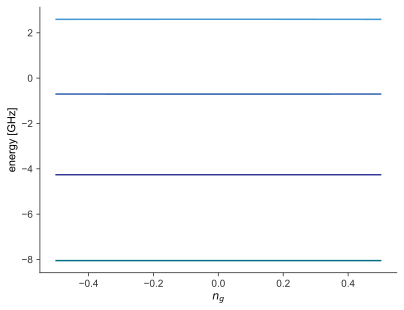

In [48]:
ng_list = np.linspace(-0.5, 0.5, 101)
tmon1.plot_evals_vs_paramvals('ng', ng_list, evals_count=4, subtract_ground=False)

In [75]:
# 取出前 4 個本徵值/態
evals, evecs = tmon1.eigensys(evals_count=10)

# 找最小值
emin = np.min(evals)
# 全部減去最小值
evals = evals - emin

print("Eigenvalues (GHz):")
print(evals)

print("\nEigenstate 1 (as vector in charge basis):")
# print(evecs)   # evecs 是一個 list of Qobj (QuTiP ket)
print("Type:", type(evecs))      # 確認型態
print("Shape:", evecs.shape)     # 形狀 (basis_dim, evals_count)
print("Size:", evecs.size)       # 總元素個數
print("NDim:", evecs.ndim)       # 維度數

Eigenvalues (GHz):
[ 0.          3.78838378  7.34692296 10.6486539  13.61240403 16.41157017
 17.84651325 21.86295358 21.95616894 28.69649193]

Eigenstate 1 (as vector in charge basis):
Type: <class 'numpy.ndarray'>
Shape: (21, 10)
Size: 210
NDim: 2


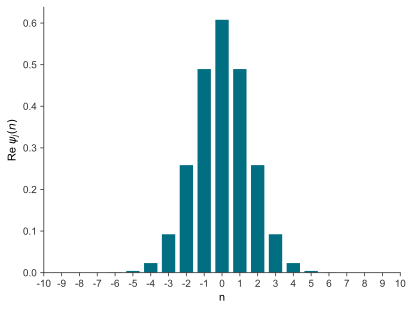

In [43]:
fig, ax = tmon1.plot_n_wavefunction(which=0, mode='real', nrange = [-ncut,ncut])
plt.show()

 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_55784/4075444551.py: 8

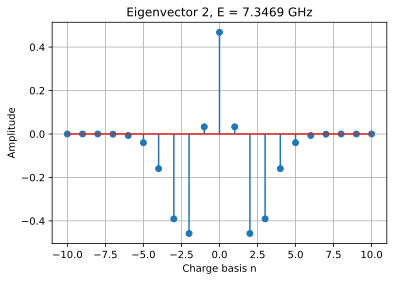

In [48]:
x = np.arange(-ncut, ncut+1)  # 橫軸 = charge basis index

# 選第幾個本徵態
k = 2  # ground state
y = evecs[:, k].real  # 可以取 real 部分

plt.figure(figsize=(6,4))
plt.stem(x, y, use_line_collection=True)
plt.xlabel("Charge basis n")
plt.ylabel("Amplitude")
plt.title(f"Eigenvector {k}, E = {evals[k]:.4f} GHz")
plt.grid(True)
plt.show()

In [ ]:
# # 取出前 4 個本徵值/態
# evals, evecs = tmon1.eigensys(evals_count=4)

# # 找最小值
# emin = np.min(evals)
# # 全部減去最小值
# evals = evals - emin

def print_eigensys_with_vectors(tmon, evals_count, vec_len):
    # 計算能量與本徵態
    evals, evecs = tmon.eigensys(evals_count=evals_count)

    for i, (energy, state) in enumerate(zip(evals, evecs)):
        # 取出前 vec_len 個分量
        coeffs = state.full().flatten()[:vec_len]
        coeffs_str = ", ".join(f"{c.real:.4f}" for c in coeffs)

        # 格式化輸出
        if i < 2:
            print(f"Level {i}: {energy:.4f} GHz (Vector: ({coeffs_str}))")
        else:
            print(f"Level {i}: {energy:.4f} GHz, half = {energy/2:.4f} GHz (Vector: ({coeffs_str}))")

print_eigensys_with_vectors(tmon1, evals_count=4, vec_len=4)

E01 (approx) = 3.800000 GHz
E01 (scqubits, ncut=10) = 3.788384 GHz
E01 different =  ['0.8990284902', '0.1254422425', '-0.0016062771', '-0.0112684030', '-0.0116098096', '-0.0116161465', '-0.0116162147', '-0.0116162151', '-0.0116162151', '-0.0116162151']  GHz


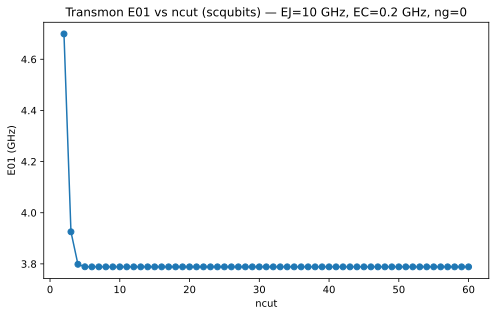

In [ ]:
# EJ, EC, ng 固定，改變 ncut 看 E01 收斂情況

EJ = 10.0  # GHz
EC = 0.2   # GHz
ng = 0.0

def E01_approx(EJ, EC):
    return np.sqrt(8*EJ*EC) - EC

def E01_scqubits(EJ, EC, ng, ncut):
    # truncated_dim 設得比你需要的能階多一點即可（例如 6）
    tmon = scq.Transmon(EJ=EJ, EC=EC, ng=ng, ncut=ncut, truncated_dim=5)
    eigenvals = tmon.eigenvals(evals_count=2, filename=None, return_spectrumdata=False)  # 取前兩個能階
    E01 = eigenvals[1] - eigenvals[0]
    return float(E01)

ncuts = list(range(2, 61))

E01_vals = [E01_scqubits(EJ, EC, ng, ncut) for ncut in ncuts]
E01_th = E01_approx(EJ, EC)
E01_th_array = np.full_like(E01_vals, E01_approx(EJ, EC), dtype=float)

E01_vals_d = E01_vals - E01_th_array

print(f"E01 (approx) = {E01_th:.6f} GHz")
print(f"E01 (scqubits, ncut=10) = {E01_scqubits(EJ, EC, ng, 10):.6f} GHz")

print("E01 different = ", [f"{x:.10f}" for x in E01_vals_d[:10]], " GHz")

plt.figure(figsize=(7,4.5))
plt.plot(ncuts, E01_vals, marker='o')
# plt.axhline(E01_th, linestyle='--')
plt.xlabel("ncut")
plt.ylabel("E01 (GHz)")
plt.title("Transmon E01 vs ncut (scqubits) — EJ=10 GHz, EC=0.2 GHz, ng=0")
plt.tight_layout()
plt.show()

In [ ]:
# truncated dimension of the transmon and the resonator
N_tmon, N_res = 4, 20
EJ = 8.568543
EC = 0.175974
fr_bare = 4.544135
g = 0.020021 #0.026230

tmon1 = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ng=0,
    ncut=10,
    truncated_dim=N_tmon     # after diagonalization, we will keep levels 0, 1, 2, and 3
)
resonator = scq.Oscillator(
    E_osc=fr,
    truncated_dim=N_res  # up to 3 photons (0,1,2,3)
)

hilbertspace = scq.HilbertSpace([tmon1, resonator])

operator1 = tmon1.n_operator()
operator2 = resonator.creation_operator() + resonator.annihilation_operator()

hilbertspace.add_interaction(
    g=g1,
    op1=(operator1, tmon1),
    op2=(operator2, resonator)
)

H = hilbertspace.hamiltonian()

eigvals, eigvecs = H.eigenstates()

# 找最小值
emin = np.min(eigvals)

# 全部減去最小值
eigvals_shifted = eigvals - emin

print("Eigenvalues (GHz):")
print(eigvals_shifted[:6])   # 前六個能階

hilbertspace.generate_lookup(ordering="LX")

Eigenvalues (GHz):
[ 0.          3.78192888  6.0041267   7.33573647  9.7845626  10.63845403]


In [ ]:
# truncated dimension of the transmon and the resonator
N_cut, N_tmon, N_res =10, 3, 10000

EJ = 8.568543
EC = 0.175974
fr_bare = 4.544135
g = 0.020021 #0.026230

tmon1 = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ng=0,
    ncut=N_cut,
    truncated_dim=N_tmon     # after diagonalization, we will keep levels 0, 1, 2, and 3
)
resonator = scq.Oscillator(
    E_osc=fr_bare,
    # l_osc= 2.0,
    truncated_dim=N_res  # up to 3 photons (0,1,2,3)
)

hilbertspace = scq.HilbertSpace([tmon1, resonator])

operator1 = tmon1.n_operator()
operator2 = resonator.creation_operator() + resonator.annihilation_operator()

hilbertspace.add_interaction(
    g=g,
    op1=(operator1, tmon1),
    op2=(operator2, resonator)
)

H = hilbertspace.hamiltonian()

# print(hilbertspace.interaction_hamiltonian())

eigvals, eigvecs = H.eigenstates()

# 找最小值
emin = np.min(eigvals)

# 全部減去最小值
eigvals_shifted = eigvals - emin

print("Eigenvalues (GHz):")
print(eigvals_shifted[:6])   # 前六個能階

# --- 1) 先建 lookup（LX）與基本量 ---
hilbertspace.generate_lookup(ordering="LX")

def energies_fix_first_index(k: int):
    max_n = N_res - 1
    i_arr = np.arange(max_n+1, dtype=int)
    E = np.array([
        hilbertspace.energy_by_dressed_index(hilbertspace.dressed_index((k, i)))
        for i in i_arr
    ])
    return i_arr, E
def energies_fix_second_index(k: int):
    max_n = N_tmon - 1
    i_arr = np.arange(max_n+1, dtype=int)
    E = np.array([
        hilbertspace.energy_by_dressed_index(hilbertspace.dressed_index((i, k)))
        for i in i_arr
    ])
    return i_arr, E

# --- 3) 拿 (0,n) 與 (1,n) 的能量與差分 ---
v0n, E0n = energies_fix_first_index(0)
v1n, E1n = energies_fix_first_index(1)
v2n, E2n = energies_fix_first_index(2)
vn0, En0 = energies_fix_second_index(0)

dE0n = np.diff(E0n)
dE1n = np.diff(E1n)
dE2n = np.diff(E2n)
dEn0 = np.diff(En0)
f01_n = E1n - E0n

# 只看前/後 5 筆（跟你之前輸出一致）
print("dE0n (first 5):", [f"{d:.6f}" for d in dE0n[:5]])
# print("dE0n (last  5):", [f"{d:.6f}" for d in dE0n[-5:]])
print("dE1n (first 5):", [f"{d:.6f}" for d in dE1n[:15]])
# print("dE1n (last  5):", [f"{d:.6f}" for d in dE1n[-5:]])
print("dEn0 (first 5):", [f"{d:.6f}" for d in dEn0[:5]])

# assert np.array_equal(n0, n1), "兩條曲線 n 範圍需一致"
# n = n0

# # ========== 理論線 ==========
# alpha = dEn0[1] - dEn0[0]
# delta = dEn0[0] - fr_bare

# # 理論 χ 與 shift
# chi = g**2 / delta
# fr_bare_theory = fr_bare - chi
# chi_eff = - (g**2 / delta) * (1 / (1 + delta/alpha))
# # chi_eff = chi - 0.0149**2 / 2 / (dEn0[1] - fr_bare)
# nc = delta**2 / (4 * g**2)

# print(f"f01 = {dEn0[0]:.4f} GHz, f12 = {dEn0[1]:.4f} GHz, alpha = {alpha:.4f} GHz")
# print(f"delta = {delta:.4f} GHz")
# print(f"chi = {chi*1000:.6f} MHz")
# print(f"Chi_eff = {chi_eff*1000:.6f} MHz")
# print(f"n_critical = {nc:.6f}")

# --- 4) 畫圖：能量 vs n（兩條線合併）---
plt.figure(figsize=(8,5))
plt.plot(v0n, E0n, marker='o', label='(0,n) energy')
plt.plot(v1n, E1n, marker='s', label='(1,n) energy')
plt.xlabel('n (second subsystem index)')
plt.ylabel('Energy (GHz)')
plt.title('E vs n for bare indices (0,n) and (1,n)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- 5) 畫圖：差分 vs n（兩條線合併）---
# 注意：diff 的橫軸對應到「相鄰 n 的間隔」，所以用 n[:-1]
# 若要砍掉最後 3 個點，可在這裡裁切

drop_last = 10

plt.figure(figsize=(8,5))
plt.plot(np.log(v0n[:-1 - drop_last]), dE0n[:-drop_last], marker='o', label='diff (0,n)')
# plt.plot(np.log(v1n[:-1 - drop_last]), dE1n[:-drop_last], marker='s', label='diff (1,n)')
# plt.plot(np.log(v2n[:-1 - drop_last]), dE2n[:-drop_last], marker='^', label='diff (2,n)')

# plt.axhline(y=fr_bare_theory, color='red', linestyle='--', label=f'Theory: fr+chi={fr_bare_theory:.3f} GHz')
plt.axhline(y=fr_bare, color='black', linestyle='--')

plt.xlabel('n (for diff: between n and n+1)')
plt.ylabel('ΔEnergy (GHz)')
plt.title(f'Diffs of energies (exclude last {drop_last})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ========== 第二張圖：能隙差 ==========
diffs = dE0n[:-drop_last] - dE1n[:-drop_last]
plt.figure(figsize=(8,5))
plt.plot(np.log(v0n[:-1 - drop_last]), diffs, marker='o', label='(0,n)-(1,n)')
plt.axhline(y=2*chi_eff, color='black', linestyle='--',
            label=f'Theory = {2*chi_eff:.4f} GHz')
plt.xlabel("n (resonator excitations)")
plt.ylabel("Energy difference (GHz)")
plt.title("Diff: (0,n) - (1,n)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(v0n, f01_n, marker='o', label='(0,n)-(1,n)')
plt.xlabel("n (resonator excitations)")
plt.ylabel("Energy difference (GHz)")
plt.title("Diff: (0,n) - (1,n)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_5433/2784673112.py: 8RuntimeWarning: divide by zero encountered in log
 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_5433/2784673112.py: 9RuntimeWarning: divide by zero encountered in log
 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_5433/2784673112.py: 10

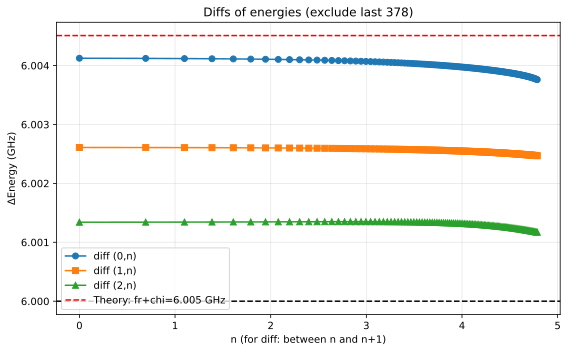

 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_5433/2784673112.py: 26

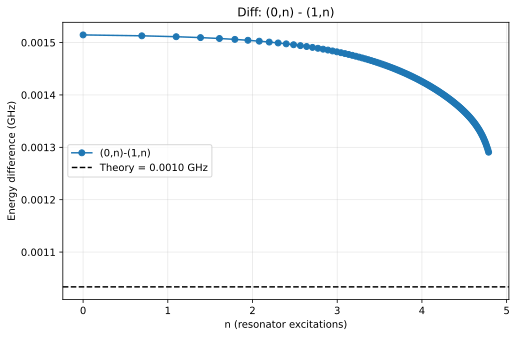

In [65]:
# --- 5) 畫圖：差分 vs n（兩條線合併）---
# 注意：diff 的橫軸對應到「相鄰 n 的間隔」，所以用 n[:-1]
# 若要砍掉最後 3 個點，可在這裡裁切

drop_last = 378

plt.figure(figsize=(8,5))
plt.plot(np.log(v0n[:-1 - drop_last]), dE0n[:-drop_last], marker='o', label='diff (0,n)')
plt.plot(np.log(v1n[:-1 - drop_last]), dE1n[:-drop_last], marker='s', label='diff (1,n)')
plt.plot(np.log(v2n[:-1 - drop_last]), dE2n[:-drop_last], marker='^', label='diff (2,n)')

plt.axhline(y=fr_bare_theory, color='red', linestyle='--', label=f'Theory: fr+chi={fr_bare_theory:.3f} GHz')
plt.axhline(y=fr_bare, color='black', linestyle='--')

plt.xlabel('n (for diff: between n and n+1)')
plt.ylabel('ΔEnergy (GHz)')
plt.title(f'Diffs of energies (exclude last {drop_last})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ========== 第二張圖：能隙差 ==========
diffs = dE0n[:-drop_last] - dE1n[:-drop_last]
plt.figure(figsize=(8,5))
plt.plot(np.log(v0n[:-1 - drop_last]), diffs, marker='o', label='(0,n)-(1,n)')
plt.axhline(y=2*chi_eff, color='black', linestyle='--',
            label=f'Theory = {2*chi_eff:.4f} GHz')
plt.xlabel("n (resonator excitations)")
plt.ylabel("Energy difference (GHz)")
plt.title("Diff: (0,n) - (1,n)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

f01 = 5.4490 GHz, f12 = 5.2299 GHz, alpha = -0.2191 GHz
delta = 0.5510 GHz, chi = 0.018150 GHz
Shift = 0.023964 GHz
n_critical = 7.589278
dE0 (first 5): ['6.014299', '6.014151', '6.014009', '6.013873', '6.013742']
dE0 (last  5): ['6.009054', '6.009029', '6.009006', '6.009167', '6.024073']
dE1 (first 5): ['6.005383', '6.005441', '6.005494', '6.005542', '6.005587']
dE1 (last  5): ['6.005723', '6.005719', '6.006120', '6.038530', '6.744622']


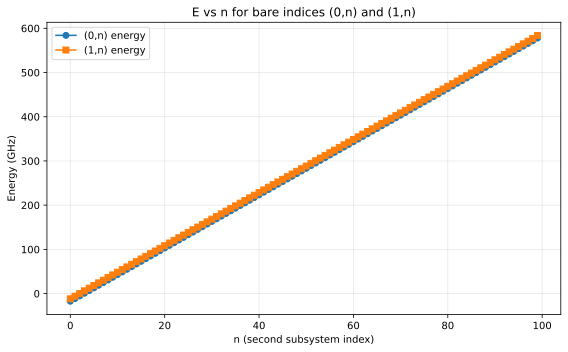

 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_5900/2237936200.py: 80RuntimeWarning: divide by zero encountered in log
 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_5900/2237936200.py: 81

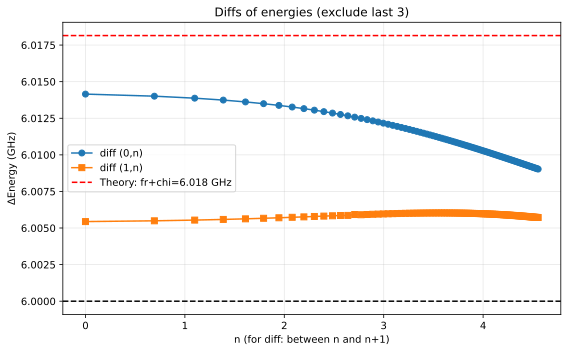

 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_5900/2237936200.py: 98

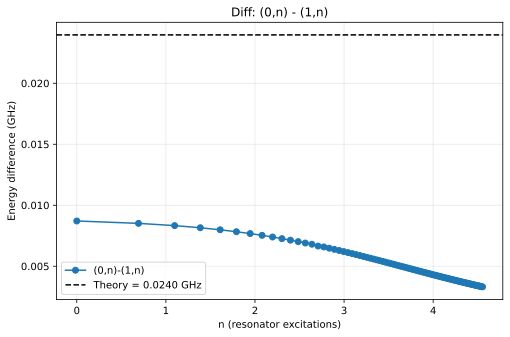

In [23]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 1) 先建 lookup（LX）與基本量 ---
# hilbertspace.generate_lookup(ordering="LX")
# dims = hilbertspace.subsystem_dims
# n_subsys = len(dims)
# assert n_subsys >= 2, "此程式假設至少有兩個子系統。"
# assert dims[0] >= 2, "第一子系統維度需 >= 2 才能取 (1,n)。"

# # 取完整能譜（能量序）
# evals_E = np.asarray(hilbertspace.eigenvals(evals_count=hilbertspace.dimension))
# lookup_flat = np.asarray(hilbertspace._data["dressed_indices"][0], dtype=int)

# --- 2) 把 (k, n, 0, 0, ...) 一次轉成能量的工具 ---
def energies_for_first_index(k: int):
    max_n = dims[1] - 1
    i_arr = np.arange(max_n + 1, dtype=int)
    # 組裸索引：(k, i, 其餘 0)
    bare = np.zeros((n_subsys, i_arr.size), dtype=int)
    bare[0, :] = k
    bare[1, :] = i_arr
    flat = np.ravel_multi_index(tuple(bare), dims)
    dressed = lookup_flat[flat]
    return i_arr, evals_E[dressed]

# --- 3) 拿 (0,n) 與 (1,n) 的能量與差分 ---
n0, E0n = energies_for_first_index(0)
n1, E1n = energies_for_first_index(1)
assert np.array_equal(n0, n1), "兩條曲線 n 範圍需一致"
n = n0

# ========== 理論線 ==========
fr_bare = 6  # GHz
g = 0.1  # GHz
eigvals = tmon.eigenvals(evals_count=3)
f01 = eigvals[1] - eigvals[0]
f12 = eigvals[2] - eigvals[1]
alpha = f12 - f01
delta = fr_bare - f01

# 理論 χ 與 shift
chi = g**2 / delta
fr_bare_theory = fr_bare + chi
shift = - 2 * (g**2 / delta) * (1 / (1 + delta/alpha))
nc = delta**2 / (4 * g**2)

print(f"f01 = {f01:.4f} GHz, f12 = {f12:.4f} GHz, alpha = {alpha:.4f} GHz")
print(f"delta = {delta:.4f} GHz, chi = {chi:.6f} GHz")
print(f"Shift = {shift:.6f} GHz")
print(f"n_critical = {nc:.6f}")

# 差分（相鄰 n 之能量差）
dE0 = np.diff(E0n)
dE1 = np.diff(E1n)

# 只看前/後 5 筆（跟你之前輸出一致）
print("dE0 (first 5):", [f"{d:.6f}" for d in dE0[:5]])
print("dE0 (last  5):", [f"{d:.6f}" for d in dE0[-5:]])
print("dE1 (first 5):", [f"{d:.6f}" for d in dE1[:5]])
print("dE1 (last  5):", [f"{d:.6f}" for d in dE1[-5:]])

# --- 4) 畫圖：能量 vs n（兩條線合併）---
plt.figure(figsize=(8,5))
plt.plot(n, E0n, marker='o', label='(0,n) energy')
plt.plot(n, E1n, marker='s', label='(1,n) energy')
plt.xlabel('n (second subsystem index)')
plt.ylabel('Energy (GHz)')
plt.title('E vs n for bare indices (0,n) and (1,n)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- 5) 畫圖：差分 vs n（兩條線合併）---
# 注意：diff 的橫軸對應到「相鄰 n 的間隔」，所以用 n[:-1]
# 若要砍掉最後 3 個點，可在這裡裁切
drop_last = 3
plt.figure(figsize=(8,5))
plt.plot(np.log(n[:-1 - drop_last]), dE0[:-drop_last], marker='o', label='diff (0,n)')
plt.plot(np.log(n[:-1 - drop_last]), dE1[:-drop_last], marker='s', label='diff (1,n)')
plt.axhline(y=fr_bare_theory, color='red', linestyle='--', label=f'Theory: fr+chi={fr_bare_theory:.3f} GHz')

 # 在 y=6 畫黑色虛線
plt.axhline(y=6, color='black', linestyle='--')

plt.xlabel('n (for diff: between n and n+1)')
plt.ylabel('ΔEnergy (GHz)')
plt.title(f'Diffs of energies (exclude last {drop_last})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ========== 第二張圖：能隙差 ==========
diffs = dE0[:-drop_last] - dE1[:-drop_last]
plt.figure(figsize=(8,5))
plt.plot(np.log(n[:-1 - drop_last]), diffs, marker='o', label='(0,n)-(1,n)')
plt.axhline(y=shift, color='black', linestyle='--',
            label=f'Theory = {shift:.4f} GHz')
plt.xlabel("n (resonator excitations)")
plt.ylabel("Energy difference (GHz)")
plt.title("Diff: (0,n) - (1,n)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 6) 如果你真的想用對數橫軸，避免 log(0)：從 n=1 起畫 ---
use_log_x = False  # 想開就改 True
if use_log_x:
    # 為了對齊 diff，從 n=1 起始；同時排除最後 drop_last 個點
    x_log = n[1:-drop_last].astype(float)
    plt.figure(figsize=(8,5))
    plt.plot(np.log(x_log), dE0[1:-drop_last], marker='o', label='diff (0,n)')
    plt.plot(np.log(x_log), dE1[1:-drop_last], marker='s', label='diff (1,n)')
    plt.xlabel('log(n)')
    plt.ylabel('ΔEnergy (GHz)')
    plt.title(f'Diffs of energies with log-x (exclude first & last {drop_last})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Diffs (first 5): ['6.002066', '6.002065', '6.002065', '6.002064', '6.002063']
Diffs (last 5): ['5.999556', '6.001642', '6.024297', '6.155924', '6.464901']


 /var/folders/vk/7986k63x6153b1c0jrkccjn80000gn/T/ipykernel_76827/2944782874.py: 39

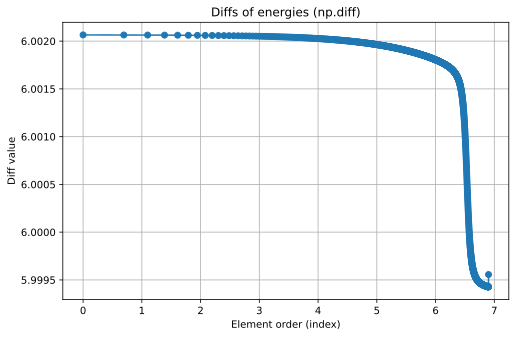

In [ ]:
# 先確保 lookup 已生成
hilbertspace.generate_lookup(ordering="LX")

# 2) 取出系統維度（每個子系統的 truncated_dim）
dims = hilbertspace.subsystem_dims
n_subsys = len(dims)
assert n_subsys >= 2, "此程式假設至少有兩個子系統。"

# 1) 準備 i 序列
max_i = dims[1] - 1
i_arr = np.arange(max_i + 1, dtype=int)

# 2) 組合所有 bare indices：shape = (n_subsys, N)
# 第一個子系統固定 0，第二個子系統跑 i，其餘子系統固定 0
bare_indices = np.zeros((n_subsys, i_arr.size), dtype=int)
bare_indices[1, :] = i_arr  # (0, i, 0, 0, ...)

# 3) 多維 → 扁平索引
flat_idx = np.ravel_multi_index(tuple(bare_indices), dims)

# 4) 查 dressed index 與對應能量（evals_E 是能量序）
lookup_flat = np.asarray(hilbertspace._data["dressed_indices"][0], dtype=int)
dressed_indices = lookup_flat[flat_idx]
evals_E = np.asarray(hilbertspace.eigenvals(evals_count=hilbertspace.dimension))
energies = evals_E[dressed_indices]   # 這裡直接得到 1D array（你要的）

# 5) 差分與輸出
diffs = np.diff(energies)
first5 = [f"{d:.6f}" for d in diffs[:10]]
last5  = [f"{d:.6f}" for d in diffs[-10:]]
print("Diffs (first 5):", first5)
print("Diffs (last 5):",  last5)

# 砍掉最後 3 個點
diffs_plot = diffs[:-6]
x = np.arange(len(diffs_plot))

plt.figure(figsize=(8,5))
plt.plot(np.log(x), diffs_plot, marker='o')
plt.xlabel("Element order (index)")
plt.ylabel("Diff value")
plt.title("Diffs of energies (np.diff)")
plt.grid(True)
plt.show()

In [8]:
print(dims)

[10, 500]


Diffs (np.diff): ['6.002066', '6.002065', '6.002065', '6.002064', '6.002063', '6.002062', '6.002062', '6.002061', '6.002060', '6.002059', '6.002059', '6.002058', '6.002057', '6.002057', '6.002056', '6.002055', '6.002054', '6.002054', '6.002053', '6.002052', '6.002052', '6.002051', '6.002050', '6.002049', '6.002049', '6.002048', '6.002047', '6.002047', '6.002046', '6.002045', '6.002044', '6.002044', '6.002043', '6.002042', '6.002042', '6.002041', '6.002040', '6.002039', '6.002039', '6.002038', '6.002037', '6.002037', '6.002036', '6.002035', '6.002035', '6.002034', '6.002033', '6.002032', '6.002032', '6.002031', '6.002030', '6.002030', '6.002029', '6.002028', '6.002028', '6.002027', '6.002026', '6.002025', '6.002025', '6.002024', '6.002023', '6.002023', '6.002022', '6.002021', '6.002021', '6.002020', '6.002019', '6.002018', '6.002018', '6.002017', '6.002016', '6.002016', '6.002015', '6.002014', '6.002014', '6.002013', '6.002012', '6.002012', '6.002011', '6.002010', '6.002010', '6.002009'

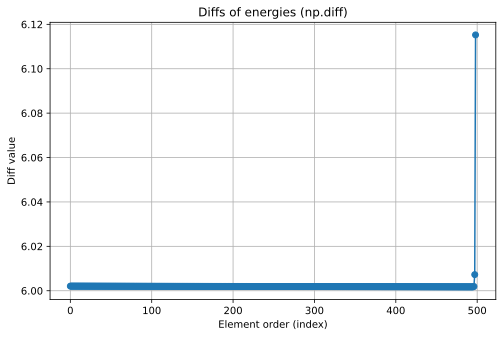

In [ ]:
# 先確保 lookup 已生成
hilbertspace.generate_lookup(ordering="LX")

# 2) 取出系統維度（每個子系統的 truncated_dim）
dims = hilbertspace.subsystem_dims
n_subsys = len(dims)
assert n_subsys >= 2, "此程式假設至少有兩個子系統。"

# 3) 取出 1D 的 lookup（裸 → 著裝(能量序) 索引）
lookup_flat = np.asarray(hilbertspace._data["dressed_indices"][0], dtype=int)

# 4) 取完整能譜（能量排序）
evals_E = hilbertspace.eigenvals(evals_count=hilbertspace.dimension)

# 5) 準備掃描 i = 0..max_i，其中 max_i 不超過第二子系統維度-1，也不超過 100
max_i = dims[1] - 1

dressed_indices = []
energies = []
i_list = []

for i in range(max_i + 1):
    # 裸索引 (0, i)；若有更多子系統，後面補 0
    bare_index = tuple([0, i] + [0] * (n_subsys - 2))

    # 轉成扁平索引 → 查 dressed index
    flat_idx = np.ravel_multi_index(bare_index, dims)
    dressed_idx = int(lookup_flat[flat_idx])

    # 用 dressed_idx 去抓能量（evals_E 是能量序）
    E = float(evals_E[dressed_idx])

    i_list.append(i)
    dressed_indices.append(dressed_idx)
    energies.append(E)

# 6) 整理成 (N, 3) 的陣列：i, dressed_index, energy
result = np.column_stack([i_list, dressed_indices, energies])

# # 可選：印前幾列檢查
# np.set_printoptions(precision=6, suppress=True)
# print("i, dressed_index, energy(GHz) → 前 10 筆：")
# print(result[:10, :])
# print(energies)

diffs = np.diff(energies)

# 前五個
first5 = [f"{d:.6f}" for d in diffs[:5]]
# 後五個
last5 = [f"{d:.6f}" for d in diffs[-5:]]
print("Diffs (first 5):", first5)
print("Diffs (last 5):", last5)

# 砍掉最後 3 個點
diffs_plot = diffs[:-3]
x = np.arange(len(diffs_plot))

plt.figure(figsize=(8,5))
plt.plot(x, diffs_plot, marker='o')
plt.xlabel("Element order (index)")
plt.ylabel("Diff value")
plt.title("Diffs of energies (np.diff)")
plt.grid(True)
plt.show()

Diffs (first 5): ['6.002066', '6.002065', '6.002065', '6.002064', '6.002063']
Diffs (last 5): ['5.999493', '5.999493', '5.999493', '5.999494', '5.999516', '5.999892', '6.004564', '6.042230', '6.217938', '6.649908']


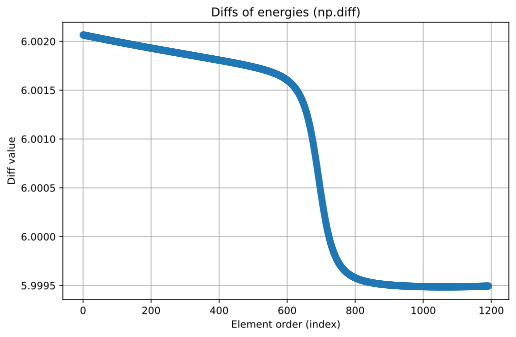

In [5]:
# 5) 差分與輸出
diffs = np.diff(energies)
first5 = [f"{d:.6f}" for d in diffs[:5]]
last5  = [f"{d:.6f}" for d in diffs[-10:]]
print("Diffs (first 5):", first5)
print("Diffs (last 5):",  last5)

# 砍掉最後 3 個點
diffs_plot = diffs[:-6]
x = np.arange(len(diffs_plot))

plt.figure(figsize=(8,5))
plt.plot(x, diffs_plot, marker='o')
plt.xlabel("Element order (index)")
plt.ylabel("Diff value")
plt.title("Diffs of energies (np.diff)")
plt.grid(True)
plt.show()

In [13]:
dressed_hamiltonian = hilbertspace.hamiltonian()
# dressed_hamiltonian.eigenenergies()

E = dressed_hamiltonian.eigenenergies()

F = eigvals
print("Type:", type(F))
print("Shape:", F.shape)
print("Size:", F.size)

E = eigvecs
print("Type:", type(E))
print("Shape:", E.shape)
print("Size:", E.size)
# print(E)

[-8.05135591 -4.26297212 -2.05135591 -0.70443295  1.73702788  2.59729799
  3.94864409  5.29556705  5.56104812  7.73702788  8.36021426  8.59729799
  9.79515734]
Type: <class 'numpy.ndarray'>
Shape: (13,)
Size: 13
Type: <class 'scqubits.io_utils.fileio_qutip.QutipEigenstates'>
Shape: (13,)
Size: 13


Spectral data:   0%|          | 0/101 [00:00<?, ?it/s]

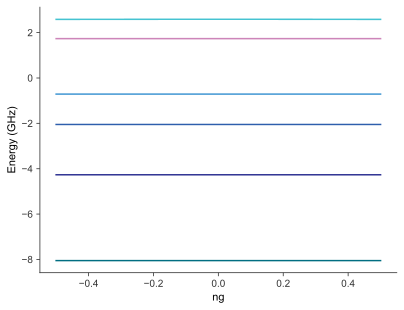

In [40]:
# 這個函式會被 scqubits 重複呼叫；務必「就地修改」同一個 t
def update_hs(ng):
    tmon.ng = float(ng)

# 掃描參數並畫譜
ng_vals = np.linspace(-0.5, 0.5, 101)
spec = hilbertspace.get_spectrum_vs_paramvals(
    param_vals=ng_vals,
    update_hilbertspace=update_hs,
    evals_count=6,
    get_eigenstates=False,
    param_name="ng",
)
fig, ax = spec.plot_evals_vs_paramvals()
ax.set_xlabel("ng"); ax.set_ylabel("Energy (GHz)")
plt.show()

# fig, ax = tmon1.plot_n_wavefunction(which=0, mode='real', nrange = [-ncut,ncut])
# plt.show()

In [ ]:
def _to_numpy_vec(vec):
    """把 Qobj 或 numpy 都轉成 1D numpy array（複數）"""
    try:
        # QuTiP Qobj
        return np.asarray(vec.full()).ravel()
    except AttributeError:
        # 已是 numpy
        arr = np.asarray(vec)
        return arr.ravel()

def _apply_mode(y, mode):
    if mode == 'real':
        return y.real
    elif mode == 'imag':
        return y.imag
    elif mode == 'abs':
        return np.abs(y)
    elif mode == 'abs_sqr':
        return np.abs(y)**2
    else:
        raise ValueError("mode 必須是 'real' | 'imag' | 'abs' | 'abs_sqr'")

def plot_eigenvector_1d(evecs, k=0, mode='real', ncut=None, title=None, marker='o'):
    """
    evecs: 可能是 (dim, M) 的 numpy 矩陣，或「長度 M 的 Qobj 列表/陣列」。
           這裡預期是 scqubits / qutip 的『每個本徵態一個 Qobj』的情況也可。
    k:     要畫第 k 個本徵態
    mode:  'real' | 'imag' | 'abs' | 'abs_sqr'
    ncut:  若提供且向量長度 = 2*ncut+1，橫軸顯示為 -ncut..+ncut
    """
    # 取得第 k 個本徵向量
    if hasattr(evecs, 'shape') and len(evecs.shape) == 2 and evecs.shape[1] > 1:
        # numpy 2D 矩陣 (dim, M)
        y = _to_numpy_vec(evecs[:, k])
    else:
        # 物件陣列或 list，每個元素是一個向量 (Qobj 或 numpy)
        y = _to_numpy_vec(evecs[k])

    y_show = _apply_mode(y, mode)

    # 橫軸
    N = y_show.size
    if ncut is not None and N == 2*ncut + 1:
        x = np.arange(-ncut, ncut+1)
        xlabel = "charge index n"
    else:
        x = np.arange(N)
        xlabel = "index"

    plt.figure(figsize=(7,4))
    plt.stem(x, y_show, use_line_collection=True, markerfmt=marker, basefmt=" ")
    plt.xlabel(xlabel)
    plt.ylabel(mode)
    if title is None:
        title = f"Eigenvector #{k} ({mode})"
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 假設你已經有
# evals, evecs = tmon1.eigensys(evals_count=4)

# # 例1：畫第 0 個本徵態的實部，且 ncut=10 → 橫軸 -10..10
# plot_eigenvector_1d(eigvecs, k=0, mode='real', ncut=10)

# # 例2：畫第 1 個本徵態的 |ψ|^2
# plot_eigenvector_1d(eigvecs, k=1, mode='real', ncut=10)

# # 例3：畫第 2 個本徵態的絕對值
# plot_eigenvector_1d(eigvecs, k=2, mode='real', ncut=10)

# # 例4：畫第 3 個本徵態的虛部，不指定 ncut（就會用索引 0..N-1）
# plot_eigenvector_1d(eigvecs, k=3, mode='real')
for i in range(12):
    plot_eigenvector_1d(eigvecs, k=i, mode='real')

In [18]:
def bare_to_dressed(bare_index, hilbertspace):
    dims = hilbertspace.subsystem_dims
    lookup_table = hilbertspace._data["dressed_indices"][0]
    flat_index = np.ravel_multi_index(bare_index, dims)
    return lookup_table[flat_index]

def dressed_to_bare(dressed_index, hilbertspace):
    dims = hilbertspace.subsystem_dims
    lookup_table = hilbertspace._data["dressed_indices"][0]
    flat_index = int(np.where(lookup_table == dressed_index)[0][0])
    return np.unravel_index(flat_index, dims)

dims = hilbertspace.subsystem_dims

# 先確保 lookup 已生成
hilbertspace.generate_lookup(ordering="LX")

# lookup_table 是 1D
lookup_table = hilbertspace._data["dressed_indices"][0]

# 你想查 (0,3)
bare_index = (0, 2)
flat_index = np.ravel_multi_index(bare_index, dims)  # 把多維索引轉成扁平
dressed_index = lookup_table[flat_index]

print(f"Bare index {bare_index} -> flat index {flat_index} -> dressed index {dressed_index}")

Bare index (0, 2) -> flat index 2 -> dressed index 6


In [20]:
dims = hilbertspace.subsystem_dims
dressed_index = 6
flat_index = int(np.where(lookup_table == dressed_index)[0][0])
bare_index = np.unravel_index(flat_index, dims)

print(f"Dressed index {dressed_index} -> flat index {flat_index} -> bare index {bare_index}")

Dressed index 6 -> flat index 2 -> bare index (0, 2)


Diffs (np.diff): ['6.002066', '6.002065', '6.002065', '6.002064', '6.002063', '6.002062', '6.002062', '6.002061', '6.002060', '6.002059', '6.002059', '6.002058', '6.002057', '6.002057', '6.002056', '6.002055', '6.002054', '6.002054', '6.002053', '6.002052', '6.002052', '6.002051', '6.002050', '6.002049', '6.002049', '6.002048', '6.002047', '6.002047', '6.002046', '6.002045', '6.002044', '6.002044', '6.002043', '6.002042', '6.002042', '6.002041', '6.002040', '6.002039', '6.002039', '6.002038', '6.002037', '6.002037', '6.002036', '6.002035', '6.002035', '6.002034', '6.002033', '6.002032', '6.002032', '6.002031', '6.002030', '6.002030', '6.002029', '6.002028', '6.002028', '6.002027', '6.002026', '6.002025', '6.002025', '6.002024', '6.002023', '6.002023', '6.002022', '6.002021', '6.002021', '6.002020', '6.002019', '6.002018', '6.002018', '6.002017', '6.002016', '6.002016', '6.002015', '6.002014', '6.002014', '6.002013', '6.002012', '6.002012', '6.002011', '6.002010', '6.002010', '6.002009'

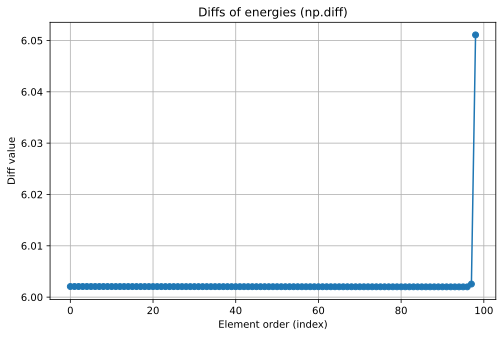

In [47]:
# 先確保 lookup 已生成
hilbertspace.generate_lookup(ordering="LX")

# 2) 取出系統維度（每個子系統的 truncated_dim）
dims = hilbertspace.subsystem_dims
n_subsys = len(dims)
assert n_subsys >= 2, "此程式假設至少有兩個子系統。"

# 3) 取出 1D 的 lookup（裸 → 著裝(能量序) 索引）
lookup_flat = np.asarray(hilbertspace._data["dressed_indices"][0], dtype=int)

# 4) 取完整能譜（能量排序）
evals_E = hilbertspace.eigenvals(evals_count=hilbertspace.dimension)

# 5) 準備掃描 i = 0..max_i，其中 max_i 不超過第二子系統維度-1，也不超過 100
max_i = dims[1] - 1

dressed_indices = []
energies = []
i_list = []

for i in range(max_i + 1):
    # 裸索引 (0, i)；若有更多子系統，後面補 0
    bare_index = tuple([0, i] + [0] * (n_subsys - 2))

    # 轉成扁平索引 → 查 dressed index
    flat_idx = np.ravel_multi_index(bare_index, dims)
    dressed_idx = int(lookup_flat[flat_idx])

    # 用 dressed_idx 去抓能量（evals_E 是能量序）
    E = float(evals_E[dressed_idx])

    i_list.append(i)
    dressed_indices.append(dressed_idx)
    energies.append(E)

# 6) 整理成 (N, 3) 的陣列：i, dressed_index, energy
result = np.column_stack([i_list, dressed_indices, energies])

# # 可選：印前幾列檢查
# np.set_printoptions(precision=6, suppress=True)
# print("i, dressed_index, energy(GHz) → 前 10 筆：")
# print(result[:10, :])
# print(energies)

diffs = np.diff(energies)

# 前五個
first5 = [f"{d:.6f}" for d in diffs[:5]]
# 後五個
last5 = [f"{d:.6f}" for d in diffs[-5:]]
print("Diffs (first 5):", first5)
print("Diffs (last 5):", last5)

# 砍掉最後 3 個點
diffs_plot = diffs[:-3]
x = np.arange(len(diffs_plot))

plt.figure(figsize=(8,5))
plt.plot(x, diffs_plot, marker='o')
plt.xlabel("Element order (index)")
plt.ylabel("Diff value")
plt.title("Diffs of energies (np.diff)")
plt.grid(True)
plt.show()

In [ ]:
# # 假設這是你拿到的 eigenvalues
# # (這裡隨便造一些資料，你可以換成 eigvals)
# np.random.seed(0)
# eigvals = np.linspace(5, 7, 300) + 0.05*np.random.randn(300)

eigvals = np.array(eigvals)
diffs = np.diff(eigvals)
print("Diffs (np.diff):", diffs)

# 統計範圍與分割數
xmin, xmax, bins = 1, 4, 101

def plot_hist(N):
    """畫前 N 個元素的累積直方圖"""
    data = diffs[:N]
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=np.linspace(xmin, xmax, bins), color="C0", alpha=0.7)
    plt.xlim(xmin, xmax)
    plt.xlabel("Eigenvalue")
    plt.ylabel("Count")
    plt.title(f"Histogram of first {N} eigenvalues")
    plt.show()

# 加一個 slider，讓你可以拖動 N
interact(plot_hist, N=IntSlider(min=1, max=len(diffs), step=1, value=50));

In [91]:
Nt_charge = tmon.n_operator()      # shape ~ (2*ncut+1, 2*ncut+1)
Nr_fock   = res.n_operator()       # shape = (N_res, N_res)

print("Nt (charge basis) shape:", Nt_charge.shape)
print("Nr (Fock basis)   shape:", Nr_fock.shape)

# 可視化一些元素（避免印太大）
np.set_printoptions(precision=3, suppress=True)
print("\nNt (charge basis) few entries:\n", Nt_charge[:7,:7])
print("\nNr (Fock basis):\n", Nr_fock)

Nt (charge basis) shape: (21, 21)
Nr (Fock basis)   shape: (3, 3)

Nt (charge basis) few entries:
 [[-10   0   0   0   0   0   0]
 [  0  -9   0   0   0   0   0]
 [  0   0  -8   0   0   0   0]
 [  0   0   0  -7   0   0   0]
 [  0   0   0   0  -6   0   0]
 [  0   0   0   0   0  -5   0]
 [  0   0   0   0   0   0  -4]]

Nr (Fock basis):
 [[ 0.+0.j    -0.-0.707j  0.+0.j   ]
 [ 0.+0.707j  0.+0.j    -0.-1.j   ]
 [ 0.+0.j     0.+1.j     0.+0.j   ]]


In [44]:
hilbertspace.generate_lookup(
    ordering = 'LX'
)
for i in range(10):   # 0 到 10
    print(hilbertspace.bare_index(i))

(0, 0)
(1, 0)
(0, 1)
(1, 1)


ValueError: Could not identify a bare index for the given dressed index 4.

In [50]:
# 定義總哈密頓量
H = hilbertspace.hamiltonian()

# Qobj 轉 numpy array
H_matrix = H.full()

# 印出矩陣
np.set_printoptions(precision=3, suppress=True)
print(H_matrix)

[[-8.051+0.j     0.   +0.j     0.   +0.j     0.   +0.j     0.   -0.077j
   0.   +0.j     0.   +0.j     0.   +0.j     0.   +0.j   ]
 [ 0.   +0.j    -2.051+0.j     0.   +0.j     0.   +0.077j  0.   +0.j
   0.   -0.109j  0.   +0.j     0.   +0.j     0.   +0.j   ]
 [ 0.   +0.j     0.   +0.j     3.949+0.j     0.   +0.j     0.   +0.109j
   0.   +0.j     0.   +0.j     0.   +0.j     0.   +0.j   ]
 [ 0.   +0.j     0.   -0.077j  0.   +0.j    -4.263+0.j     0.   +0.j
   0.   +0.j     0.   +0.j     0.   +0.105j  0.   +0.j   ]
 [ 0.   +0.077j  0.   +0.j     0.   -0.109j  0.   +0.j     1.737+0.j
   0.   +0.j     0.   -0.105j  0.   +0.j     0.   +0.149j]
 [ 0.   +0.j     0.   +0.109j  0.   +0.j     0.   +0.j     0.   +0.j
   7.737+0.j     0.   +0.j     0.   -0.149j  0.   +0.j   ]
 [ 0.   +0.j     0.   +0.j     0.   +0.j     0.   +0.j     0.   +0.105j
   0.   +0.j    -0.704+0.j     0.   +0.j     0.   +0.j   ]
 [ 0.   +0.j     0.   +0.j     0.   +0.j     0.   -0.105j  0.   +0.j
   0.   +0.149j  0.   +0.j

In [51]:
eigvals, eigvecs = H.eigenstates()

# 找最小值
emin = np.min(eigvals)

# 全部減去最小值
eigvals_shifted = eigvals - emin

print("Eigenvalues (GHz):")
print(eigvals_shifted[:6])   # 前六個能階

Eigenvalues (GHz):
[ 0.     3.785  6.002  7.343  9.786 12.006]
